<a href="https://colab.research.google.com/github/PayalJain-05/Network-Flow-Optimization-System/blob/main/Network_Slow_Optimisation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
importimportgygyimportgyimportimport networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

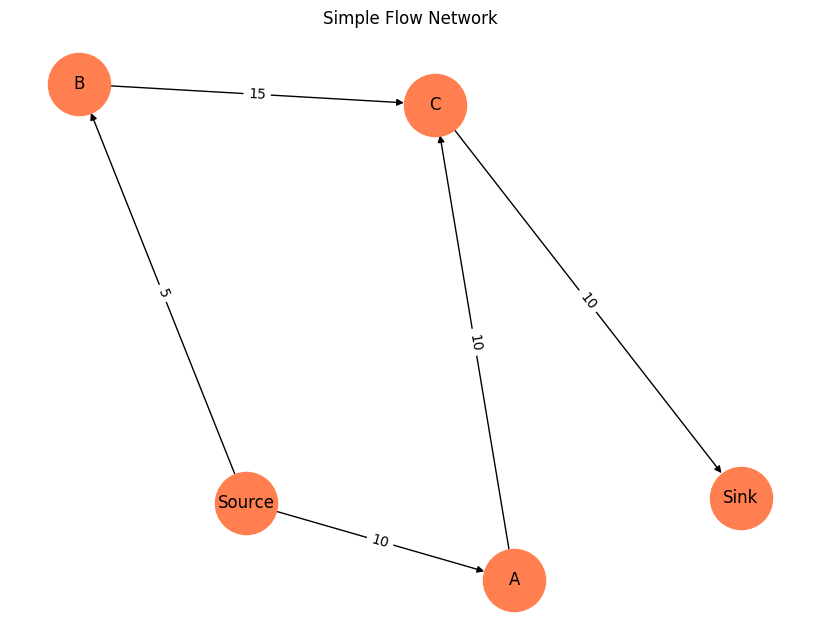

Simple Graph Max Flow: 10

Flow Distribution:
Source → A : 5
Source → B : 5
A → C : 5
B → C : 5
C → Sink : 10


In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# SIMPLE GRAPH (Concept Demo)
# -------------------------------

simple_graph = nx.DiGraph()

# Create edges with capacities
simple_graph.add_edge("Source", "A", capacity=10)
simple_graph.add_edge("Source", "B", capacity=5)

simple_graph.add_edge("A", "C", capacity=10)
simple_graph.add_edge("B", "C", capacity=15)

simple_graph.add_edge("C", "Sink", capacity=10)

# Visualization
pos = nx.spring_layout(simple_graph, seed=42)

plt.figure(figsize=(8,6))
nx.draw(simple_graph, pos, with_labels=True, node_color='coral', node_size=2000)

labels = nx.get_edge_attributes(simple_graph, 'capacity')
nx.draw_networkx_edge_labels(simple_graph, pos, edge_labels=labels)

plt.title("Simple Flow Network")
plt.show()

# Max Flow Calculation
flow_value_simple, flow_dict_simple = nx.maximum_flow(simple_graph, "Source", "Sink")

print("Simple Graph Max Flow:", flow_value_simple)
print("\nFlow Distribution:")

for u in flow_dict_simple:
    for v in flow_dict_simple[u]:
        if flow_dict_simple[u][v] > 0:
            print(f"{u} → {v} : {flow_dict_simple[u][v]}")

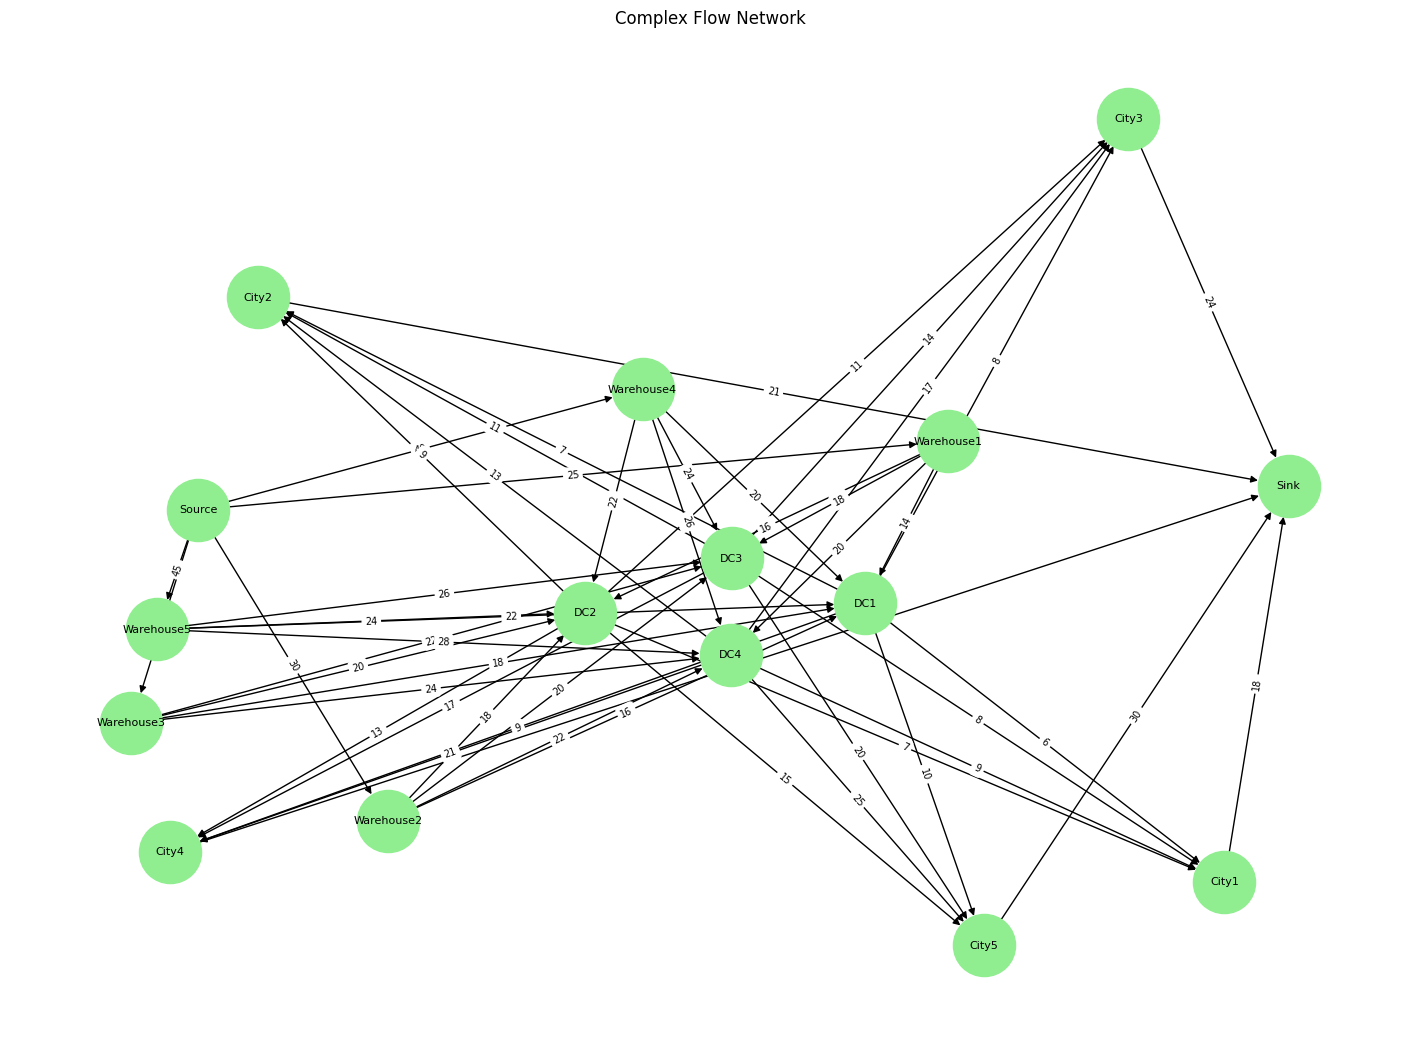

Complex Graph Max Flow: 120

Flow Distribution:
Source → Warehouse1 : 1
Source → Warehouse2 : 24
Source → Warehouse3 : 26
Source → Warehouse4 : 31
Source → Warehouse5 : 38
Warehouse1 → DC4 : 1
Warehouse2 → DC3 : 14
Warehouse2 → DC4 : 10
Warehouse3 → DC3 : 22
Warehouse3 → DC4 : 4
Warehouse4 → DC2 : 14
Warehouse4 → DC3 : 2
Warehouse4 → DC4 : 15
Warehouse5 → DC1 : 15
Warehouse5 → DC2 : 23
DC1 → City1 : 6
DC1 → City2 : 1
DC1 → City3 : 8
DC2 → City1 : 7
DC2 → City2 : 9
DC2 → City3 : 11
DC2 → City4 : 10
DC3 → City2 : 11
DC3 → City3 : 5
DC3 → City4 : 17
DC3 → City5 : 5
DC4 → City1 : 5
DC4 → City5 : 25
City1 → Sink : 18
City2 → Sink : 21
City3 → Sink : 24
City4 → Sink : 27
City5 → Sink : 30

Bottleneck Edges: [('City1', 'Sink'), ('City3', 'Sink'), ('City4', 'Sink'), ('City5', 'Sink'), ('City2', 'Sink')]

Before Optimization: 120
After Optimization: 130
Improvement: 10


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# COMPLEX GRAPH (Real System)
# -------------------------------

complex_graph = nx.DiGraph()

# Source to Warehouses
for i in range(1, 6):
    complex_graph.add_edge("Source", f"Warehouse{i}", capacity=20 + i*5)

# Warehouses to Distribution Centers
for i in range(1, 6):
    for j in range(1, 5):
        complex_graph.add_edge(f"Warehouse{i}", f"DC{j}", capacity=10 + (i+j)*2)

# Distribution Centers to Cities
for i in range(1, 5):
    for j in range(1, 6):
        complex_graph.add_edge(f"DC{i}", f"City{j}", capacity=5 + (i*j))

# Cities to Sink
for i in range(1, 6):
    complex_graph.add_edge(f"City{i}", "Sink", capacity=15 + i*3)

# Visualization
pos = nx.spring_layout(complex_graph, seed=42)

plt.figure(figsize=(14,10))
nx.draw(complex_graph, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_size=8)

labels = nx.get_edge_attributes(complex_graph, 'capacity')
nx.draw_networkx_edge_labels(complex_graph, pos, edge_labels=labels, font_size=7)

plt.title("Complex Flow Network")
plt.show()

# Max Flow Calculation
flow_value_complex, flow_dict_complex = nx.maximum_flow(complex_graph, "Source", "Sink")

print("Complex Graph Max Flow:", flow_value_complex)
print("\nFlow Distribution:")

for u in flow_dict_complex:
    for v in flow_dict_complex[u]:
        if flow_dict_complex[u][v] > 0:
            print(f"{u} → {v} : {flow_dict_complex[u][v]}")

# Minimum Cut (Bottleneck Detection)
cut_value, (set1, set2) = nx.minimum_cut(complex_graph, "Source", "Sink")

cut_edges = []
for u in set1:
    for v in complex_graph.successors(u):
        if v in set2:
            cut_edges.append((u, v))

print("\nBottleneck Edges:", cut_edges)

# Scenario Testing (Optimization)
# Increase capacity of one bottleneck edge (example)
complex_graph["City2"]["Sink"]["capacity"] += 10

new_flow, _ = nx.maximum_flow(complex_graph, "Source", "Sink")

print("\nBefore Optimization:", flow_value_complex)
print("After Optimization:", new_flow)
print("Improvement:", new_flow - flow_value_complex)